In [48]:
import pandas as pd

In [49]:
end_year = 2024
region_analysis = "Europe_and_North_America_and_Japan"

global_universe = pd.read_csv(f"./data/Global_Universe/Global_Universe_{region_analysis}_{end_year}.csv")

In [50]:
# Split global_universe into currency-based universes
usa_universe = global_universe[global_universe["curcdd"].eq("USD")].copy()
EU_universe = global_universe[global_universe["curcdd"].eq("EUR")].copy()
Japan_universe = global_universe[global_universe["curcdd"].eq("JPY")].copy()

In [51]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def corr_heatmap_xy(
    df: pd.DataFrame,
    y_vars: list[str],
    x_vars: list[str],
    *,
    method: str = "pearson",
    dropna: bool = True,
    annot: bool = True,
    fmt: str = ".2f",
    cmap: str = "vlag",
    center: float = 0.0,
    vmin: float | None = -1.0,
    vmax: float | None = 1.0,
    figsize: tuple[float, float] | None = None,
    title: str | None = None,
    save_path: str | None = None,
):
    """Plot correlation heatmap for selected row vars (y) vs column vars (x).

    Returns (corr_df, ax).
    """
    if dropna:
        cols = list(dict.fromkeys([*y_vars, *x_vars]))
        data = df.loc[:, cols].dropna(how="any")
    else:
        data = df

    corr_full = data.corr(method=method, numeric_only=True)
    corr_xy = corr_full.reindex(index=y_vars, columns=x_vars)

    if figsize is None:
        # Simple heuristic: scale with number of vars
        figsize = (max(6.0, 0.6 * len(x_vars)), max(4.5, 0.45 * len(y_vars)))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_xy,
        ax=ax,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        square=False,
        cbar_kws={"label": f"{method} correlation"},
    )
    ax.set_xlabel("x variables")
    ax.set_ylabel("y variables")
    if title:
        ax.set_title(title)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    return corr_xy, ax


In [70]:

signal_columns = global_universe.columns[29:33]
#accounting_columns = global_universe.columns[14:24]
accounting_columns = global_universe.columns[33:]


C:\Users\chris\AppData\Local\Temp\ipykernel_37532\253127909.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


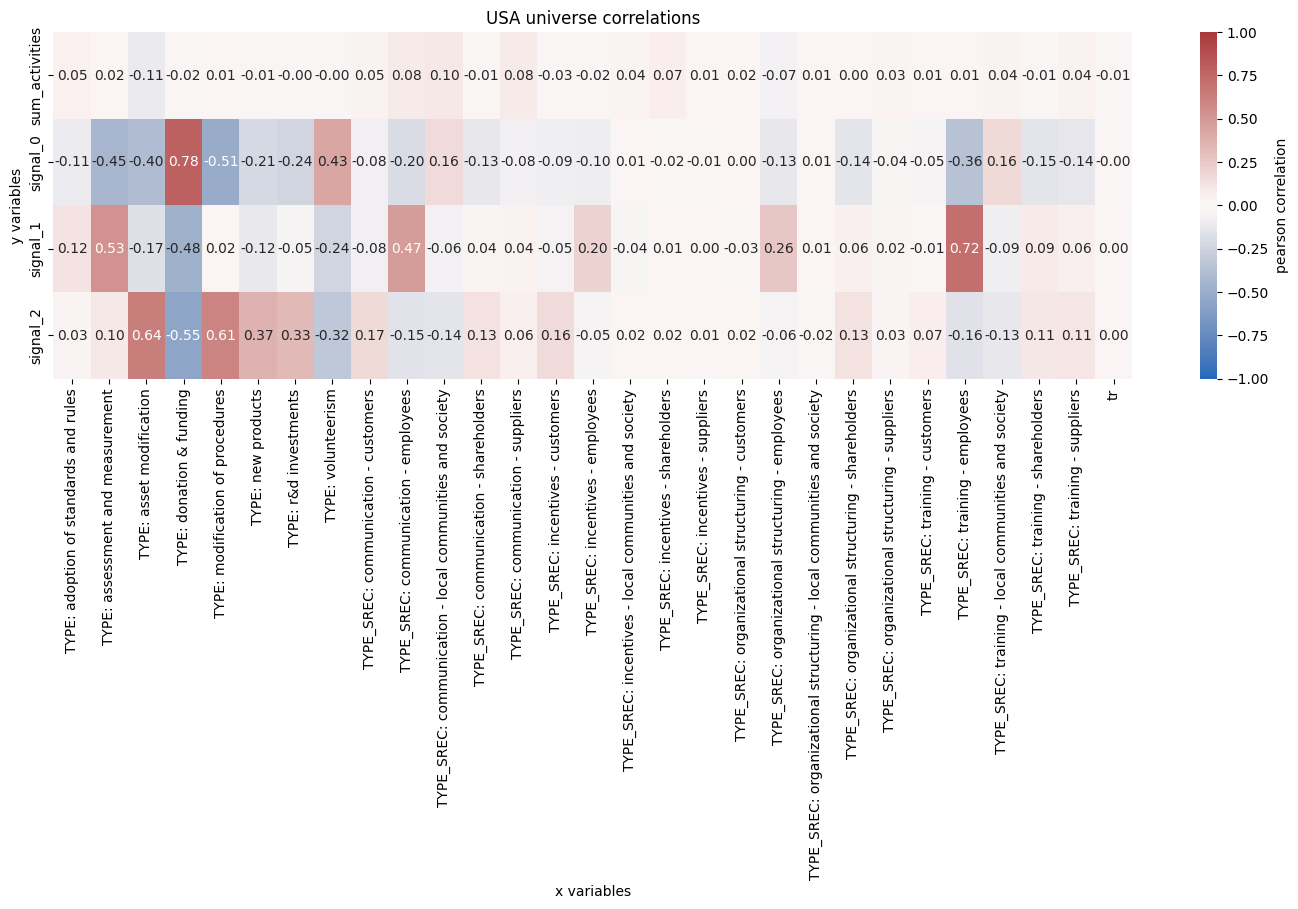

In [71]:
corr_xy, ax = corr_heatmap_xy(
    usa_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    title="USA universe correlations",
)

C:\Users\chris\AppData\Local\Temp\ipykernel_37532\253127909.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


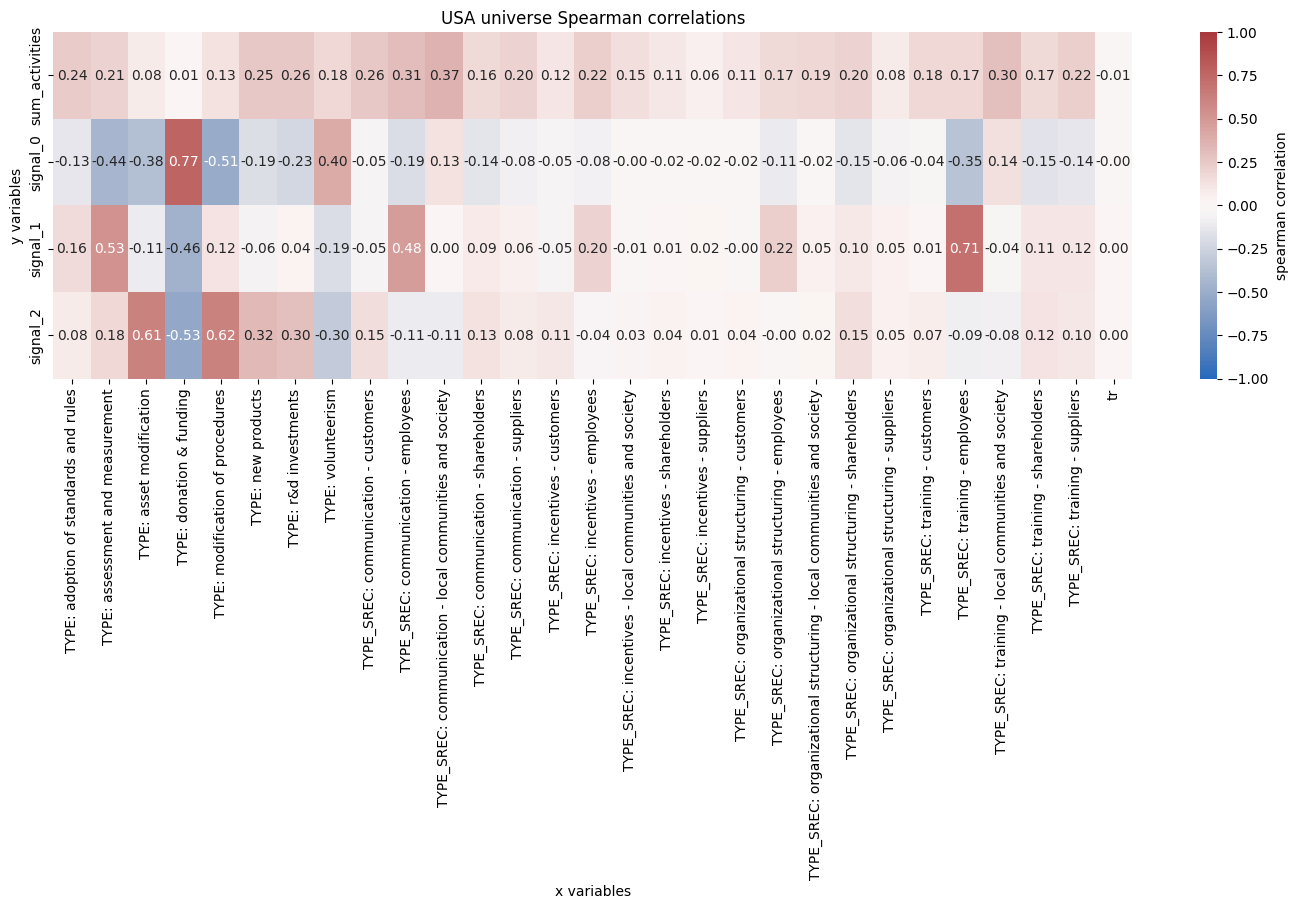

In [72]:
# Spearman version (rank correlation)
_corr_xy_spearman, _ax = corr_heatmap_xy(
    usa_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    method="spearman",
    title="USA universe Spearman correlations",
)


C:\Users\chris\AppData\Local\Temp\ipykernel_37532\253127909.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


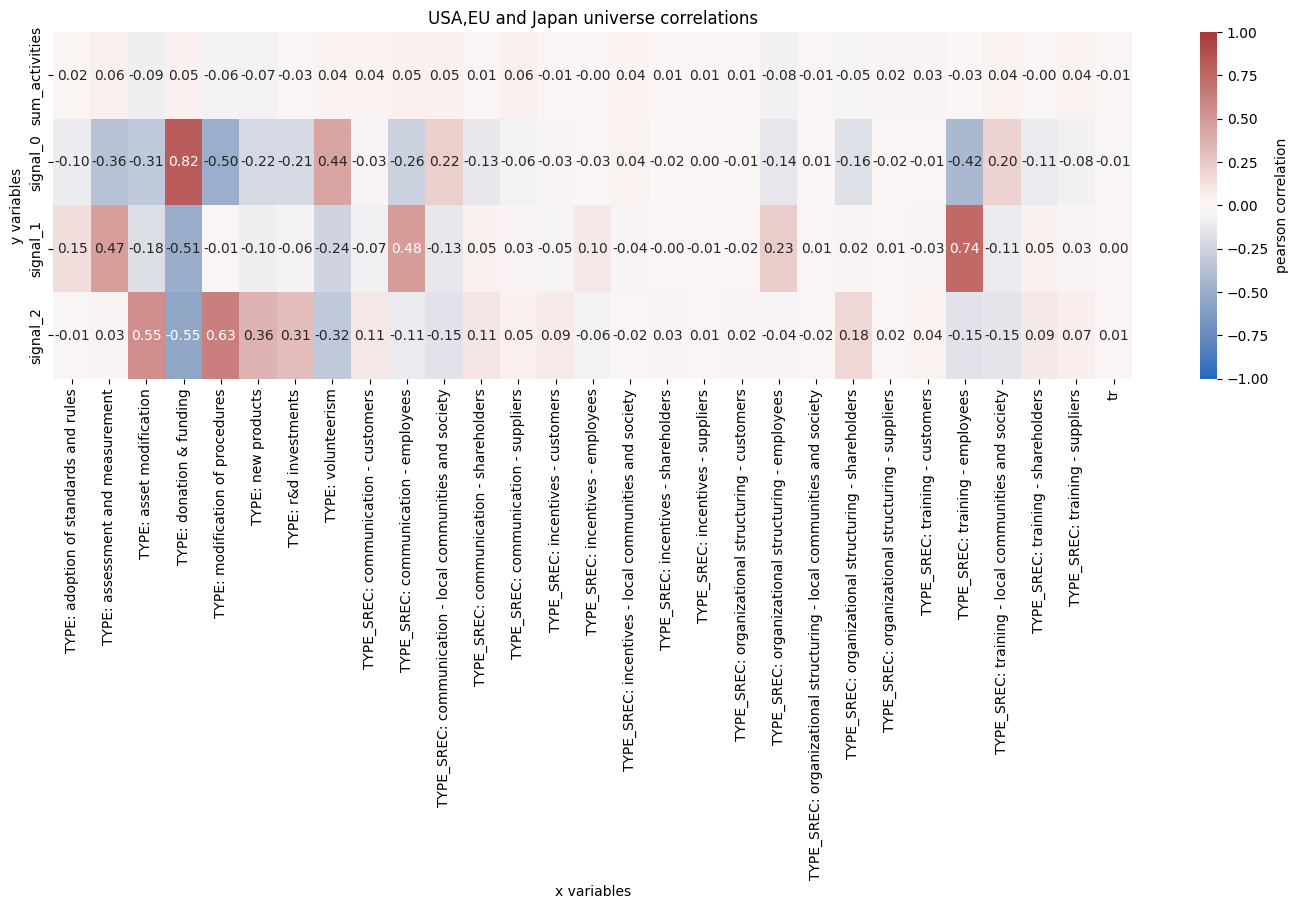

In [73]:
corr_xy, ax = corr_heatmap_xy(
    global_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    title="USA,EU and Japan universe correlations",
)

C:\Users\chris\AppData\Local\Temp\ipykernel_37532\253127909.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


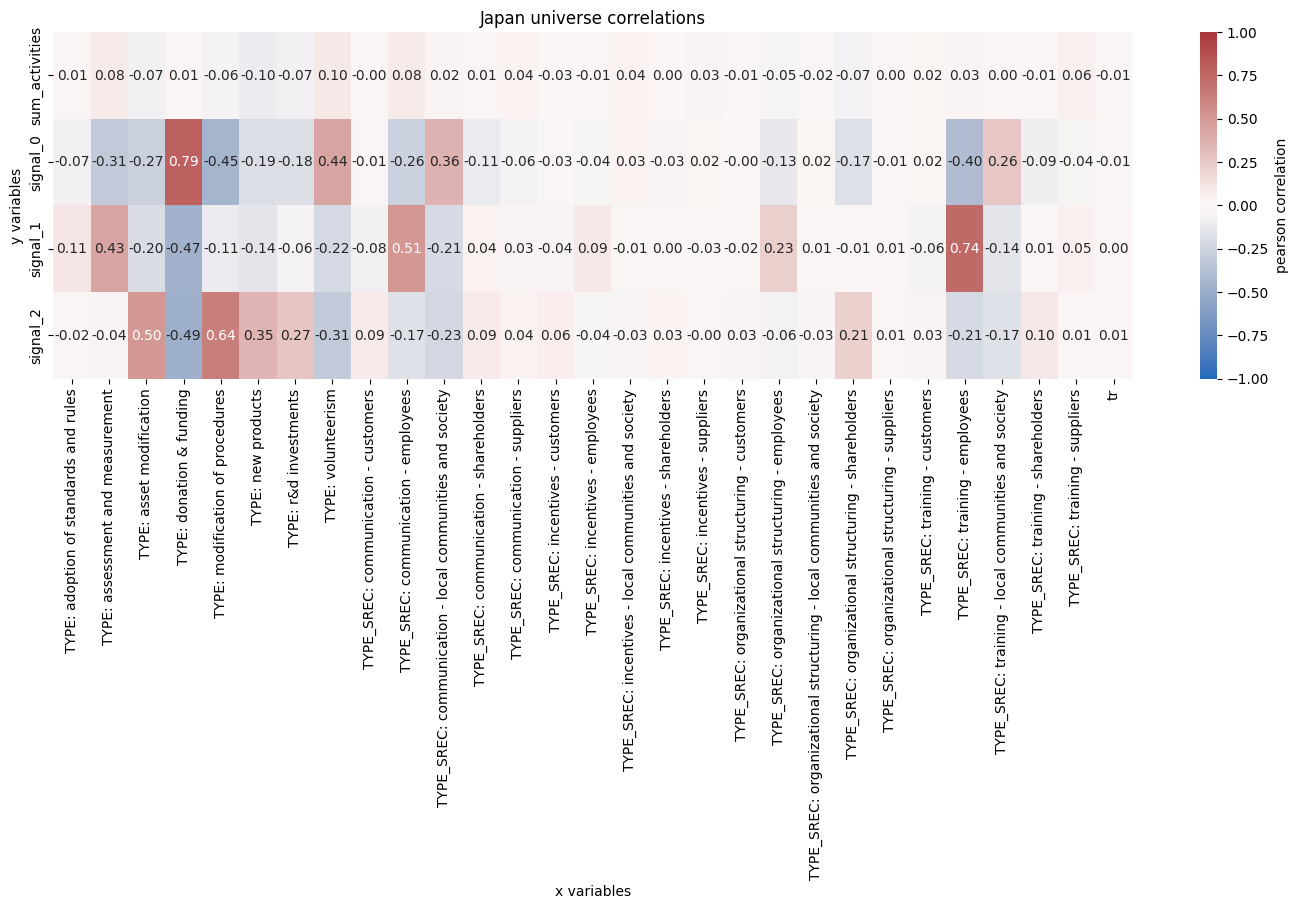

In [74]:
corr_xy, ax = corr_heatmap_xy(
    japan_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    title="Japan universe correlations",
)

C:\Users\chris\AppData\Local\Temp\ipykernel_37532\253127909.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


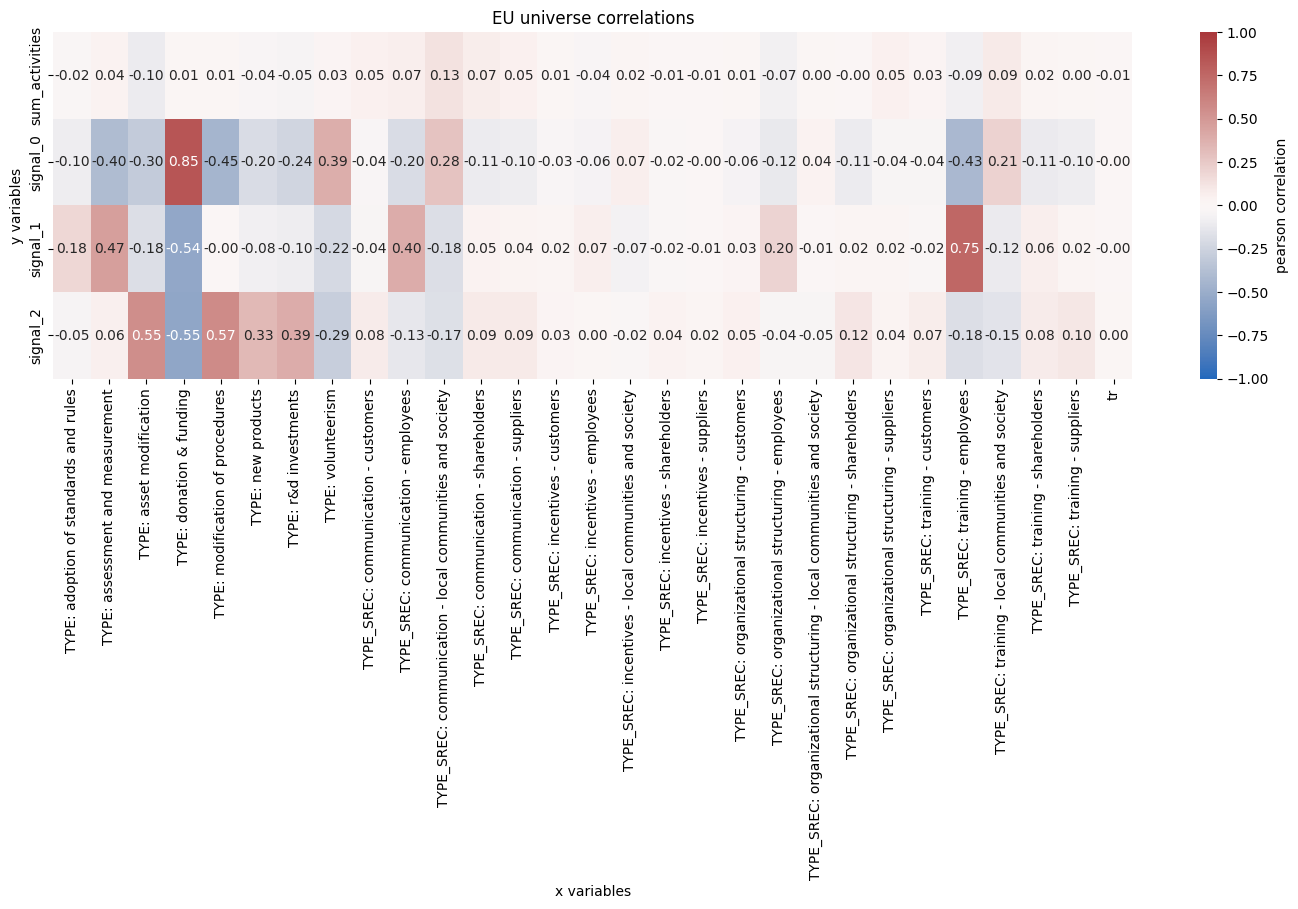

In [75]:
corr_xy, ax = corr_heatmap_xy(
    eu_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    title="EU universe correlations",
)